# H3 Cell Rasterize + Band Stacking Demo

**A complete polygon → H3 polyfill → per-band rasterize → multi-band stack pipeline,
demonstrated on DEM elevation isobands.**

## What this notebook shows

This notebook demonstrates the full H3-cell rasterization workflow:

1. **Load a DEM** — SRTM tile covering the San Francisco Bay Area (`srtm_n37w123.tif`, EPSG:4326).
2. **Quantize into elevation isobands** — every 100 m produces a filled polygon ring.
   Each ring becomes a *band level* (analogous to a signal-strength threshold in a
   wireless-coverage pipeline).
3. **H3 polyfill** — convert each band polygon to the set of H3 cells at resolution 8
   whose centers fall inside the polygon.
4. **Shared grid spec** — `rx.rst_h3_gridspec` snaps a single aligned canvas over all
   bands combined, so the rasterized tiles are pixel-aligned and can be stacked.
5. **Per-band rasterize** — `rx.rst_h3_rasterize_agg` burns each band's H3 cells onto
   the shared canvas, producing one coverage tile per elevation band.
6. **Stack** — `rx.rst_frombands_agg` assembles the per-band tiles into a single
   multi-band GeoTIFF; `plot_raster` visualizes the stack as a false-colour composite.

## Telco / coverage-analysis analogy

Replace *elevation band* with *signal-strength contour* and you have a
transmitter-coverage pipeline:

| DEM demo | Coverage-analysis equivalent |
|---|---|
| Elevation isoband polygon | Signal contour polygon (e.g. -80 dBm zone) |
| `band_level` (integer) | Threshold index (e.g. tier 1 / tier 2 / …) |
| H3 polyfill at res 8 | H3 coverage cells per threshold |
| Multi-band stacked tile | Multi-threshold stacked coverage raster |

## Runtime requirement

Run on a Databricks cluster or Serverless compute. The DEM is read from the
GeoBrix sample-data Unity Catalog Volume; outputs are empty until executed on
a cluster. See `README.md` for setup instructions.

---
_Last Modified: June 24, 2026_

## 1. Install GeoBrix

The lightweight `[light,viz]` extras are sufficient — no JAR or GDAL init script
required (when using the lightweight tier). The notebook can run on Serverless compute.


In [0]:
# Install GeoBrix with lightweight raster + visualization extras.
# Replace the file:// path with your staged wheel location
%pip install --quiet --disable-pip-version-check --force-reinstall --no-deps "geobrix @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.4.0-py3-none-any.whl"
%pip install --quiet "geobrix[light,viz] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.4.0-py3-none-any.whl"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## 2. Imports and registration


In [0]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import rasterio
from rasterio.features import shapes as rio_shapes
from pyspark.sql import functions as F

import h3

# GeoBrix lightweight tier — runs on Serverless.
from databricks.labs.gbx.pyrx import functions as rx
from databricks.labs.gbx.ds.register import register
from databricks.labs.gbx.viz import plot_raster, plot_file, cells_as_gdf, grid_as_gdf

# Register pyrx SQL UDFs and H3 UDTFs (rst_h3_rastertogridavg, etc.).
rx.register(spark)
register(spark)

## 3. DEM path and parameters

The SRTM tile `srtm_n37w123.tif` covers the San Francisco Bay Area (N37, W123) — including the SF Peninsula, Marin headlands (Mt Tamalpais, ~784 m), and East Bay hills. It ships with the GeoBrix sample-data Volume.


In [0]:
# --- paths ---------------------------------------------------------------
DEM_PATH = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/elevation/srtm_n37w123.tif"

# --- parameters -----------------------------------------------------------
H3_RESOLUTION = 8          # resolution 8 hexagons (~0.74 km² each)
BAND_STEP_M   = 100        # elevation isoband interval in metres
MIN_ELEV_M    = 0          # lower bound for isobands (sea-level baseline)
MAX_ELEV_M    = 800        # upper bound; SF Bay Area peaks at ~986 m (Mt Tamalpais area)

print(f"DEM : {DEM_PATH}")
print(f"H3 resolution : {H3_RESOLUTION}")
print(f"Band step : {BAND_STEP_M} m  (bands from {MIN_ELEV_M} to {MAX_ELEV_M} m)")

### Stage the sample DEM

The demo reads a 1°×1° SRTM tile (`srtm_n37w123.tif`, San Francisco Bay Area). This cell downloads it from the public AWS Terrain Tiles dataset and writes it to the Volume **once** — idempotent, and safe on Serverless (uses rasterio's bundled GDAL, no `gdal_translate` CLI). Download + conversion happen in node-local temp; the final file is copied to the Volume sequentially (FUSE-safe).

In [0]:
# Ensure the sample DEM is staged on the Volume (idempotent; Serverless- and classic-safe).
import os, shutil

if not os.path.exists(DEM_PATH):
    from databricks.labs.gbx.sample import get_temp_dir            # shipped in the geobrix wheel
    from databricks.labs.gbx.sample._bundle import download_srtm_to_path

    tmp = get_temp_dir()                                           # node-local scratch (NOT the Volume)
    tile = "N37W123"                                               # 1x1 deg SRTM tile; SW corner 37N, 123W
    hgt = download_srtm_to_path(tile, tmp / f"{tile}.hgt", f"SRTM {tile}")   # public AWS Terrain Tiles S3

    import rasterio                                                # bundled GDAL reads .hgt; no gdal CLI needed
    local_tif = tmp / "srtm_n37w123.tif"
    with rasterio.open(str(hgt)) as src:
        profile = {**src.profile, "driver": "GTiff"}
        with rasterio.open(str(local_tif), "w", **profile) as dst:
            dst.write(src.read())

    os.makedirs(os.path.dirname(DEM_PATH), exist_ok=True)          # Volume root must pre-exist; subdirs OK
    shutil.copy(str(local_tif), DEM_PATH)                          # FUSE-safe sequential copy to the Volume
    print(f"staged {DEM_PATH}")
else:
    print(f"{DEM_PATH} already present")

## 4. Step 1 — Load DEM and extract elevation isobands

Rasterio reads the DEM locally on the driver. We quantize the elevation array
into bands of `BAND_STEP_M` metres, then use `rasterio.features.shapes` to
extract the boundary polygons for each band level as GeoJSON-like dicts.

Each band polygon represents the area where the terrain exceeds that elevation
threshold — directly analogous to a signal-coverage contour polygon.


In [0]:
# Read DEM on the driver (rasterio, FUSE-mounted Volume path).
with rasterio.open(DEM_PATH) as src:
    dem_transform = src.transform
    dem_crs       = src.crs
    dem_nodata    = src.nodata
    elevation     = src.read(1, masked=True).astype("float32")

print(f"DEM shape    : {elevation.shape}")
print(f"CRS          : {dem_crs}")
print(f"Transform    : {dem_transform}")
print(f"Elev range   : {float(elevation.min()):.0f} – {float(elevation.max()):.0f} m")

# Build the list of isoband thresholds.
thresholds = list(range(
    int(MIN_ELEV_M),
    int(min(MAX_ELEV_M, float(elevation.max()))),
    BAND_STEP_M,
))
print(f"Thresholds   : {thresholds} m ({len(thresholds)} bands)")

# For each threshold level, extract a binary mask (elevation > threshold) and
# run rasterio.features.shapes to get polygons in the DEM's CRS (EPSG:4326).
isoband_rows = []  # (band_level, geojson_geometry)

for level in thresholds:
    mask = (~elevation.mask) & (elevation.data > level)
    mask_uint8 = mask.astype("uint8")
    for geom, val in rio_shapes(mask_uint8, mask=mask_uint8, transform=dem_transform):
        if val == 1:
            isoband_rows.append({"band_level": level, "geometry": geom})

print(f"Total polygon shapes : {len(isoband_rows)}")

#### Step 1 — render the DEM

The source elevation tile via `gbx.viz.plot_file` (auto-decimation + per-band 2–98% percentile stretch; single-band → viridis).

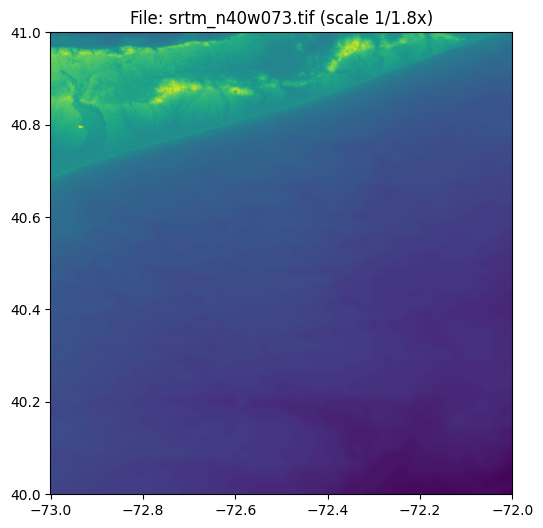

In [0]:
# Render the source DEM straight from the Volume path.
plot_file(DEM_PATH, fig_w=8, fig_h=6)

## 5. Step 2 — H3 polyfill: polygons → H3 cells

For each isoband polygon we call `h3.polygon_to_cells` to fill it with H3
hexagonal cells at `H3_RESOLUTION`. We store cell IDs as **64-bit integers**
(via `h3.str_to_int`) because PySpark's `LongType` maps to Scala `Long`.

This step runs on the **driver** for the demo (DEM is driver-side). In a
production pipeline, you would Spark-parallelize the polygon rows and call
`h3.polygon_to_cells` inside a pandas UDF or UDTF to fan out across executors.


In [0]:
from pyspark.sql.types import LongType, IntegerType, StructType, StructField

cell_rows = []  # (band_level: int, cellid: int)

for row in isoband_rows:
    geom = row["geometry"]
    level = row["band_level"]

    coords = geom["coordinates"]
    if geom["type"] == "Polygon":
        rings = coords
    elif geom["type"] == "MultiPolygon":
        rings = coords[0]  # use the largest ring for demo brevity
    else:
        continue

    # rasterio shapes returns (lon, lat) tuples; h3.LatLngPoly expects (lat, lon).
    outer = [(lat, lon) for lon, lat in rings[0]]
    holes = [[(lat, lon) for lon, lat in ring] for ring in rings[1:]]

    try:
        poly = h3.LatLngPoly(outer, *holes)
        cells = h3.polygon_to_cells(poly, H3_RESOLUTION)
    except Exception:
        continue

    for c in cells:
        cell_rows.append((level, h3.str_to_int(c)))

print(f"Total (band_level, cellid) rows : {len(cell_rows)}")
# Deduplicate: a cell may be covered by multiple ring polygons for the same band.
cell_rows = list(set(cell_rows))
print(f"After dedup : {len(cell_rows)}")

# Create a Spark DataFrame with explicit schema.
schema = StructType([
    StructField("band_level", IntegerType(), False),
    StructField("cellid",     LongType(),    False),
])
cells_df = spark.createDataFrame(cell_rows, schema=schema)
cells_df.groupBy("band_level").count().orderBy("band_level").show()

#### Step 2 — render the H3 polyfill (efficient: dissolved per band)

`cells_as_gdf(..., dissolve_by="band_level")` merges each band's cells into one footprint polygon — far fewer geometries than one row per cell — then plots colored by elevation band.

<Axes: >

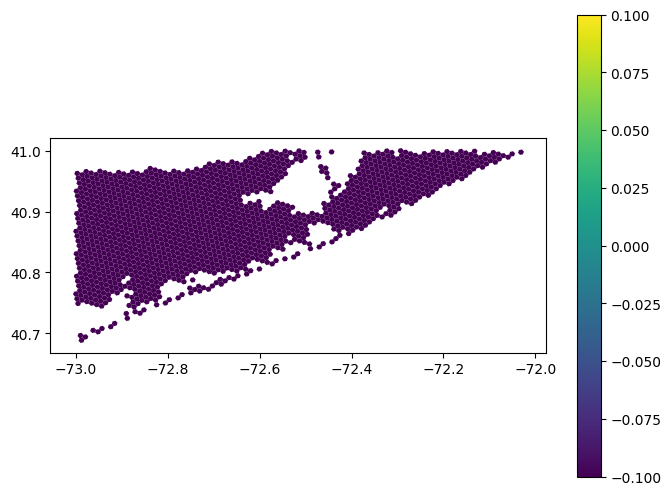

In [0]:
# Dissolve cells per band -> one footprint polygon per band_level (efficient render).
bands_gdf = cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"]) #, dissolve_by="band_level")
bands_gdf.plot(column="band_level", cmap="viridis", legend=True, figsize=(8, 6))

## 6. Step 3 — Shared grid spec via `rst_h3_gridspec`

`rx.rst_h3_gridspec` computes a pixel-snapped bounding box and pixel dimensions
that span **all** H3 cells across **all** band levels. Because we pass no
grouping column here (we want a single shared canvas), it returns a single-row
DataFrame with a `grid` struct.

Using the same `grid` for every band ensures all per-band tiles are spatially
aligned — a prerequisite for `rst_frombands_agg` to produce a coherent stack.


In [0]:
# Compute the shared canvas over ALL cells (no grouping column → one grid row).
grid_df = rx.rst_h3_gridspec(cells_df, "cellid")
grid_row = grid_df.first()
g = grid_row["grid"]

print("Shared canvas grid spec:")
print(f"  xmin={g['xmin']:.6f}  ymin={g['ymin']:.6f}")
print(f"  xmax={g['xmax']:.6f}  ymax={g['ymax']:.6f}")
print(f"  pixel_size={g['pixel_size']:.6f}")
print(f"  width={g['width']}  height={g['height']}  srid={g['srid']}")

# Broadcast the grid constants to all rows so rst_h3_rasterize_agg
# receives the same extent per group.
cells_with_grid = cells_df.withColumn("xmin",   F.lit(g["xmin"]))\
                           .withColumn("ymin",   F.lit(g["ymin"]))\
                           .withColumn("xmax",   F.lit(g["xmax"]))\
                           .withColumn("ymax",   F.lit(g["ymax"]))\
                           .withColumn("width",  F.lit(g["width"]))\
                           .withColumn("height", F.lit(g["height"]))

#### Step 3 — render the shared canvas over the cells (multiple layers)

`grid_as_gdf` turns the grid spec into the canvas rectangle; overlaying it on the per-band cell footprints with folium `.explore(m=...)` puts **multiple layers on one map** — you see the single shared grid framing every band.

In [0]:
# Multi-layer: per-band cell footprints + the shared-canvas rectangle on ONE folium map.
bands_gdf = cells_as_gdf(cells_df, "cellid", extra_cols=["band_level"]) #, dissolve_by="band_level")
grid_gdf = grid_as_gdf(g)  # g = grid_row["grid"] -> the shared canvas spec

m = bands_gdf.explore(column="band_level", cmap="viridis", name="H3 cells by band")
grid_gdf.explore(m=m, color="red", style_kwds={"fill": False, "weight": 2}, name="shared canvas")
# On Databricks, if the folium map does not render inline: displayHTML(m._repr_html_())
m

## 7. Step 4 — Per-band rasterize with `rst_h3_rasterize_agg`

`rst_h3_rasterize_agg` burns a group's H3 cells onto the shared canvas,
producing a presence mask (1.0 where a cell's centroid falls, NoData elsewhere).
Supplying the explicit extent from `rst_h3_gridspec` guarantees every per-band
tile has identical pixel dimensions — which is required for stacking.

We group by `band_level` so each elevation threshold produces one tile.


In [0]:
# One rasterized tile per band level, all on the shared canvas.
bands_df = cells_with_grid.groupBy("band_level").agg(
    rx.rst_h3_rasterize_agg(
        "cellid",
        xmin="xmin",
        ymin="ymin",
        xmax="xmax",
        ymax="ymax",
        width="width",
        height="height",
    ).alias("tile")
)

# Persist to avoid re-computing during subsequent agg.
bands_df = bands_df.orderBy("band_level")
print(f"Band tiles: {bands_df.count()} rows")
bands_df.select("band_level",
                F.expr("gbx_rst_width(tile)  AS px_width"),
                F.expr("gbx_rst_height(tile) AS px_height"),
                F.expr("gbx_rst_numbands(tile) AS numbands")).show()

## 8. Inspect a single band tile

Before stacking, visualize one band to confirm the rasterization looks correct.
The viridis colormap shows covered H3 cells (value 1.0); NoData is transparent.


Visualizing band_level=0 m


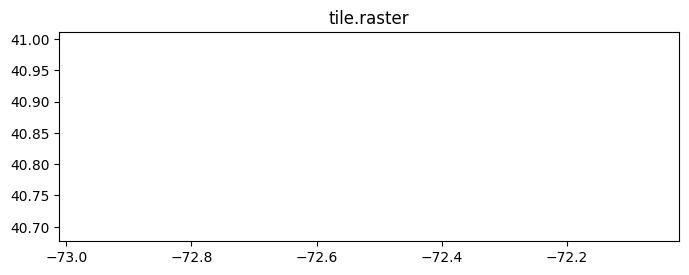

In [0]:
# Collect the lowest (densest) band for inspection.
sample_row = bands_df.orderBy("band_level").first()
print(f"Visualizing band_level={sample_row['band_level']} m")

plot_raster(sample_row["tile"]["raster"], fig_w=8, fig_h=6)


## 9. Step 5 — Stack bands with `rst_frombands_agg`

`rst_frombands_agg` assembles the per-band tiles into a single multi-band
GeoTIFF, ordered by `band_level` ascending. Band 1 in the stacked raster
corresponds to the lowest elevation threshold (densest coverage); the highest
band corresponds to the highest threshold (sparsest coverage).

In a wireless-coverage pipeline this multi-band tile would represent overlapping
coverage tiers — e.g. Band 1 = outdoor coverage, Band 2 = indoor marginal,
Band 3 = indoor reliable — ready for downstream analysis or PMTiles export.


In [0]:
# Add a sequential band_index starting at 1 so rst_frombands_agg orders correctly.
from pyspark.sql.window import Window

w = Window.orderBy("band_level")
indexed = bands_df.withColumn(
    "band_index",
    F.row_number().over(w).cast("int"),
)

# Stack all per-band tiles into one multi-band tile.
stacked_df = indexed.agg(
    rx.rst_frombands_agg("tile", "band_index").alias("stacked")
)

stacked_row = stacked_df.first()
stacked_tile = stacked_row["stacked"]
print("Stacked tile schema:", stacked_tile.asDict().keys())

# Quick metadata check via SQL accessors.
meta = stacked_df.selectExpr(
    "gbx_rst_numbands(stacked) AS n_bands",
    "gbx_rst_width(stacked)    AS width",
    "gbx_rst_height(stacked)   AS height",
    "gbx_rst_srid(stacked)     AS srid",
).first()
print(f"Bands: {meta['n_bands']}  Width: {meta['width']}  Height: {meta['height']}  SRID: {meta['srid']}")


## 10. Visualize the stacked multi-band raster

With three or more bands `plot_raster` renders the first three as an RGB
composite (R = band 1, G = band 2, B = band 3). The result is a false-colour
elevation map: pixels covered by all three bands appear white; those covered
only by the lowest threshold appear red; uncovered pixels are black (NoData
masked by the renderer).

The fact that the stack reconstructs a recognisable terrain pattern confirms
that the polyfill → rasterize → stack pipeline is spatially consistent.


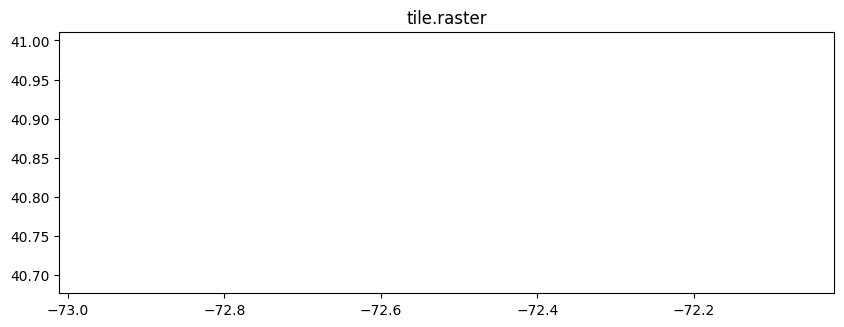

In [0]:
# Render the stacked raster.
# 3+ bands → RGB composite (R=band-1, G=band-2, B=band-3).
# 1 or 2 bands → viridis grayscale (auto-selected by plot_raster).
plot_raster(stacked_tile["raster"], fig_w=10, fig_h=8)


## 11. Summary and next steps

This notebook demonstrated the full H3-cell rasterization pipeline:

| Step | Function | Output |
|---|---|---|
| DEM → isobands | `rasterio.features.shapes` | GeoJSON polygon per band |
| Polygon → H3 cells | `h3.polygon_to_cells` | `(band_level, cellid)` rows |
| Shared canvas | `rx.rst_h3_gridspec` | `grid` struct (xmin…height) |
| H3 cells → tile | `rx.rst_h3_rasterize_agg` | single-band tile per band |
| Stack bands | `rx.rst_frombands_agg` | multi-band GeoTIFF tile |
| Visualize | `plot_raster` | inline matplotlib figure |

### Adapting to a wireless-coverage pipeline

Replace the elevation DEM with contour polygons derived from RF propagation
model outputs. Each contour polygon represents signal strength above a threshold
(e.g. −80 dBm for outdoor, −95 dBm for indoor marginal). The rest of the
pipeline is identical — the stacked raster encodes multi-tier coverage that can
be exported as PMTiles for web visualization or joined against subscriber
location data for churn analysis.

### Further reading

- [GeoBrix RasterX API](https://databrickslabs.github.io/geobrix/docs/api/rasterx) — full function reference
- [EO-Series notebooks](../eo-series/) — STAC download, band stacking, clipping pipeline
